In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
df = pd.read_csv(r"D:\Narendra Work Files\Data Analyst\CSV Files\dirty_cafe_sales.csv")
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,UNKNOWN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02


# Check Data Quality

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    10000 non-null  str  
 1   Item              9667 non-null   str  
 2   Quantity          9862 non-null   str  
 3   Price Per Unit    9821 non-null   str  
 4   Total Spent       9827 non-null   str  
 5   Payment Method    7421 non-null   str  
 6   Location          6735 non-null   str  
 7   Transaction Date  9841 non-null   str  
dtypes: str(8)
memory usage: 625.1 KB


In [6]:
df.describe()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,10000,9667,9862,9821,9827,7421,6735,9841
unique,10000,10,7,8,19,5,4,367
top,TXN_1961373,Juice,5,3.0,6.0,Digital Wallet,Takeaway,UNKNOWN
freq,1,1171,2013,2429,979,2291,3022,159


In [7]:
df.isnull().sum()

Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64

# Clean the Data

In [10]:
df.replace("UNKNOWN", np.nan, inplace=True)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,NaN,NaN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,NaN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02


Fill Missing Values

Item

In [14]:
df.fillna({"Item": df["Item"].mode()[0]}, inplace=True)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,NaN,NaN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,NaN,2023-08-30
9996,TXN_9659401,Juice,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02


Quantity

In [10]:
df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")
df["Quantity"] = df["Quantity"].fillna(df["Quantity"].median())

Price Per Unit

In [11]:
df["Price Per Unit"] = pd.to_numeric(df["Price Per Unit"], errors="coerce")
df["Price Per Unit"] = df["Price Per Unit"].fillna(df["Price Per Unit"].median())

Total Spent

In [12]:
df["Total Spent"] = pd.to_numeric(df["Total Spent"], errors="coerce")
df["Total Spent"] = df["Total Spent"].fillna(df["Quantity"] * df["Price Per Unit"])

Payment Method

In [13]:
df["Payment MEthod"] = df["Payment Method"].fillna(df["Payment Method"].mode()[0])

Location

In [14]:
df["Location"] = df["Location"].fillna(df["Location"].mode()[0])

Transaction Date

In [15]:
df["Transaction Date"] = pd.to_datetime(df["Transaction Date"],errors="coerce")
df["Transaction Date"] = df["Transaction Date"].fillna(df["Transaction Date"].mode()[0])

# Verify Cleaning

In [14]:
df.isnull().sum()

Transaction ID         0
Item                 333
Quantity               0
Price Per Unit         0
Total Spent            0
Payment Method      2579
Location               0
Transaction Date       0
Payment MEthod         0
dtype: int64

In [16]:
df.columns.tolist()

['Transaction ID',
 'Item',
 'Quantity',
 'Price Per Unit',
 'Total Spent',
 'Payment Method',
 'Location',
 'Transaction Date',
 'Payment MEthod']

In [ ]:
Fix the duplicate column

In [17]:
df["Payment Method"] = df["Payment Method"].fillna(df["Payment MEthod"])
df.drop("Payment MEthod", axis=1, inplace=True)

Fill remaining missing values

In [18]:
df["Item"] = df["Item"].fillna(df["Item"].mode()[0])
df["Payment Method"] = df["Payment Method"].fillna(df["Payment Method"].mode()[0])

In [19]:
df.isnull().sum()

Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
dtype: int64

# Create a Revenue Column Check

Sometimes Total Spent may still contain incorrect values. Verify:

In [24]:
df["Calculated Total"] = df["Quantity"] * df["Price Per Unit"]
df[["Quantity","Price Per Unit","Total Spent","Calculated Total"]].head()                                        

,Quantity,Price Per Unit,Total Spent,Calculated Total
0,2.0,2.0,4.0,4.0
1,4.0,3.0,12.0,12.0
2,4.0,1.0,4.0,4.0
3,2.0,5.0,10.0,10.0
4,2.0,2.0,4.0,4.0


# Chart

# 1.Top Selling Items

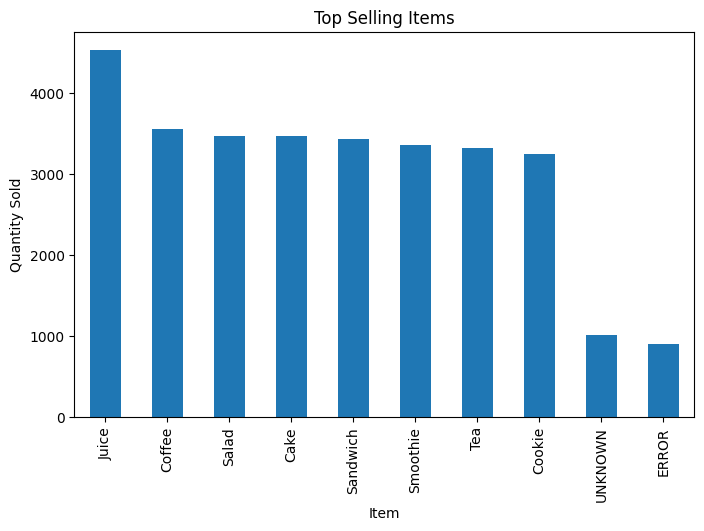

In [27]:
item_qty = df.groupby("Item")["Quantity"].sum().sort_values(ascending=False)

item_qty.plot(kind="bar", figsize=(8,5))
plt.title("Top Selling Items")
plt.ylabel("Quantity Sold")
plt.show()

# 2.Revenue by Item

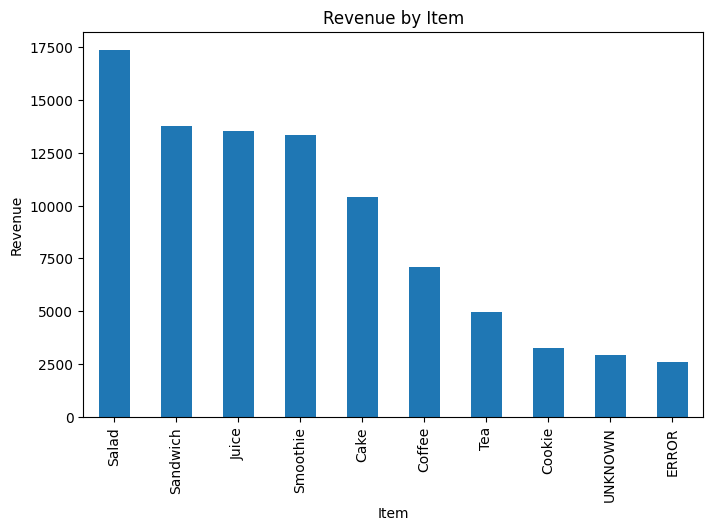

In [28]:
revenue = df.groupby("Item")["Total Spent"].sum().sort_values(ascending=False)

revenue.plot(kind="bar", figsize=(8,5))
plt.title("Revenue by Item")
plt.ylabel("Revenue")
plt.show()

# 3.Payment Method Usage

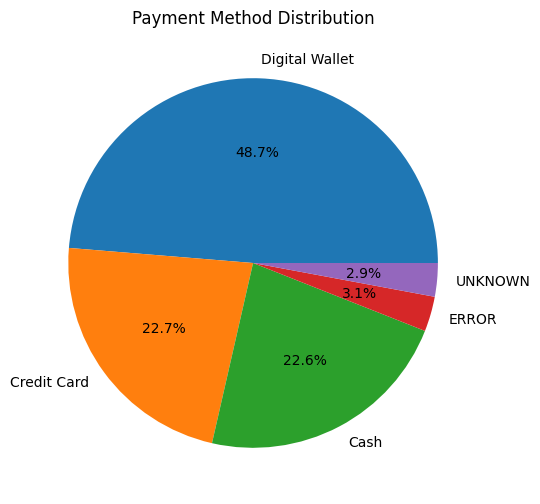

In [31]:
df["Payment Method"].value_counts().plot(kind="pie",autopct="%1.1f%%",figsize=(6,6))
plt.title("Payment Method Distribution")
plt.ylabel("")
plt.show()

# 4.Revenue by Location

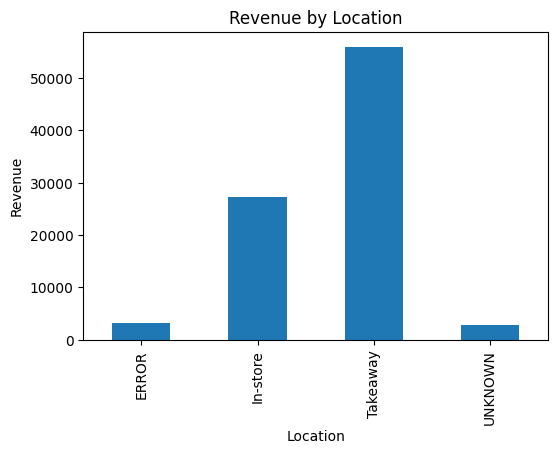

In [32]:
location_rev = df.groupby("Location")["Total Spent"].sum()

location_rev.plot(kind="bar", figsize=(6,4))
plt.title("Revenue by Location")
plt.ylabel("Revenue")
plt.show()

# 5.Monthly Sales Trend

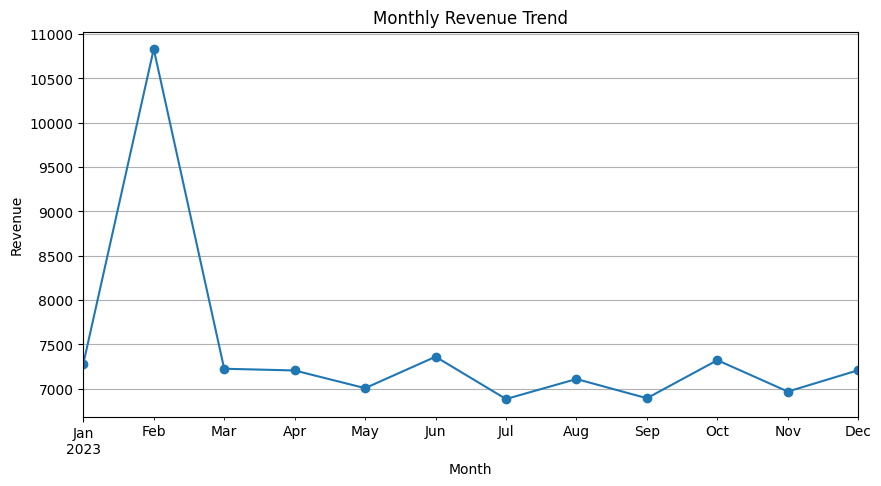

In [35]:
df["Month"] = df["Transaction Date"].dt.to_period("M")
monthly_sales = df.groupby("Month")["Total Spent"].sum()
monthly_sales.plot(marker="o", figsize=(10,5))
plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue")
plt.grid(True)
plt.show()

# Useful Insights

Best-selling item

In [36]:
df.groupby("Item")["Quantity"].sum().sort_values(ascending=False).head()

Item
Juice       4530.0
Coffee      3551.0
Salad       3469.0
Cake        3467.0
Sandwich    3428.0
Name: Quantity, dtype: float64

Highest revenue item

In [37]:
df.groupby("Item")["Total Spent"].sum().sort_values(ascending=False).head()

Item
Salad       17365.0
Sandwich    13751.0
Juice       13544.0
Smoothie    13362.0
Cake        10413.0
Name: Total Spent, dtype: float64

Average order value

In [38]:
"Average Order Value:", round(df["Total Spent"].mean(),2)

('Average Order Value:', np.float64(8.93))

Most used payment method

In [39]:
df["Payment Method"].value_counts()

Payment Method
Digital Wallet    4870
Credit Card       2273
Cash              2258
ERROR              306
UNKNOWN            293
Name: count, dtype: int64

Revenue by location

In [40]:
df.groupby("Location")["Total Spent"].sum()

Location
ERROR        3252.5
In-store    27260.5
Takeaway    56000.5
UNKNOWN      2794.0
Name: Total Spent, dtype: float64